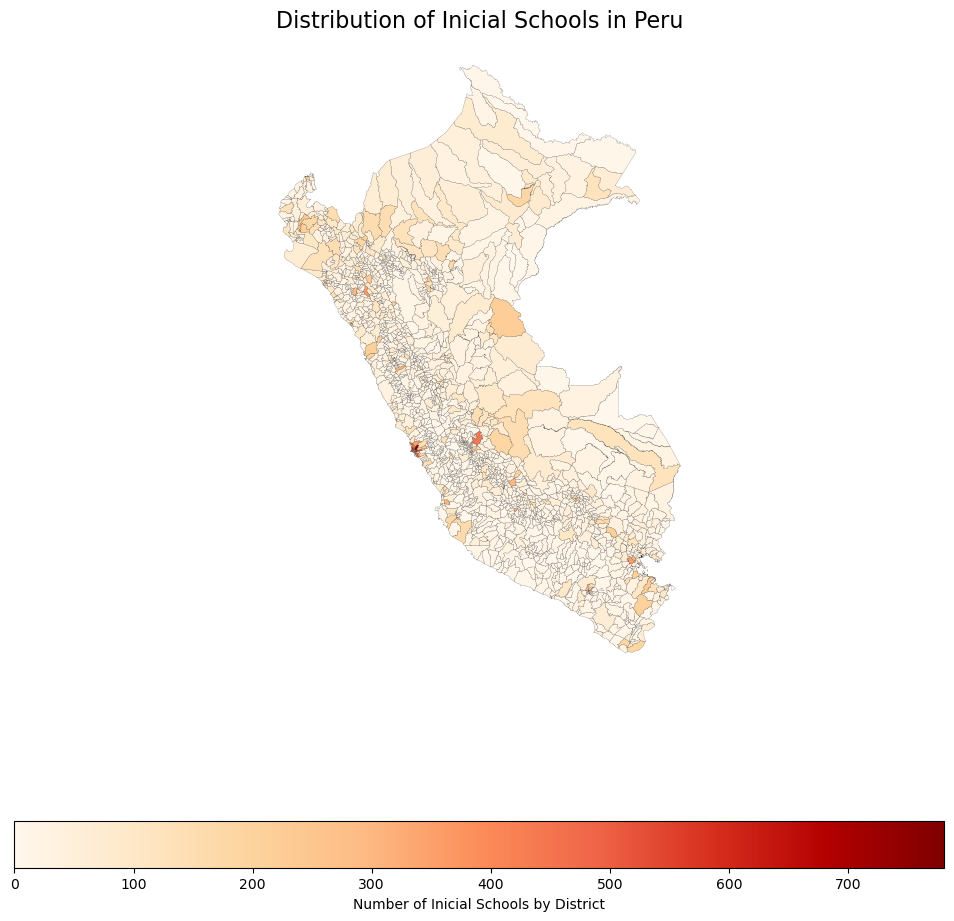

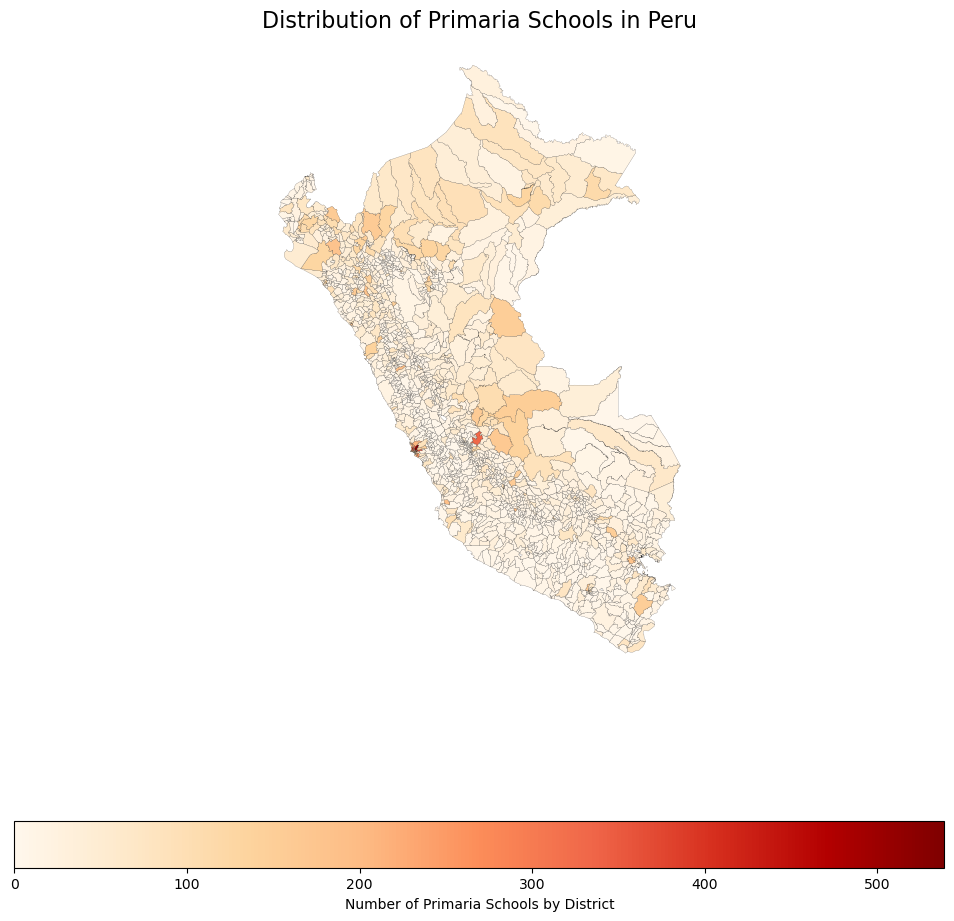

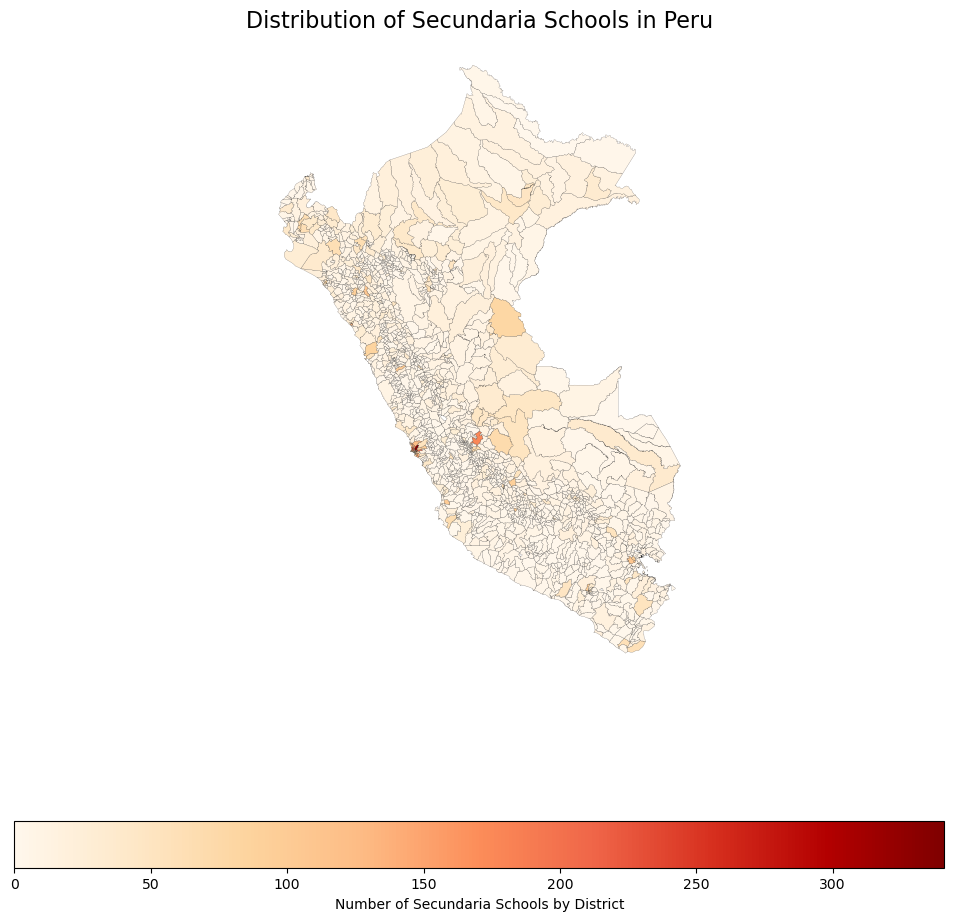

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

#Task 1: Static Maps by School Level - for all districts

# Load Peru districts shapefile
shapefile_path = r"C:\Users\brfm1\OneDrive\Documentos\Geospatial Analysis of Schools in Peru\DISTRITOS\DISTRITOS_inei.shp"
peru_gdf = gpd.read_file(shapefile_path)

# Rename columns to ensure matching names
peru_gdf.rename(columns={'NOMBDEP': 'Departamento', 'NOMBDIST': 'Distrito'}, inplace=True)

# Load MINEDU school data
df = pd.read_excel(r"C:\Users\brfm1\OneDrive\Documentos\Geospatial Analysis of Schools in Peru\listado_iiee.xlsx")

# Filter data by school levels
levels = ['Inicial', 'Primaria', 'Secundaria']
dfs_level = {}
for level in levels:
    dfs_level[level] = df[df['Nivel / Modalidad'].str.contains(level, case=False, na=False)]

# Aggregate school counts by district
counts_level = {}
for level in levels:
    counts_level[level] = dfs_level[level].groupby('Distrito').size().reset_index(name='num_schools')

# Merge and plot static maps for each level
for level in levels:
    merged_gdf = peru_gdf.merge(counts_level[level], on='Distrito', how='left')
    merged_gdf['num_schools'] = merged_gdf['num_schools'].fillna(0)

    fig, ax = plt.subplots(figsize=(12, 12))
    merged_gdf.plot(column='num_schools', cmap='OrRd', linewidth=0.1, ax=ax,
                    edgecolor='black', legend=True,
                    legend_kwds={'label': f"Number of {level} Schools by District",
                                 'orientation': "horizontal"})

    ax.set_title(f'Distribution of {level} Schools in Peru', fontsize=16)
    ax.axis('off')
    plt.show()


C:\Users\brfm1\AppData\Local\Temp\ipykernel_27200\1929970853.py:54: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  high_schools_within.plot(ax=ax, color='green', markersize=20, label='High Schools')


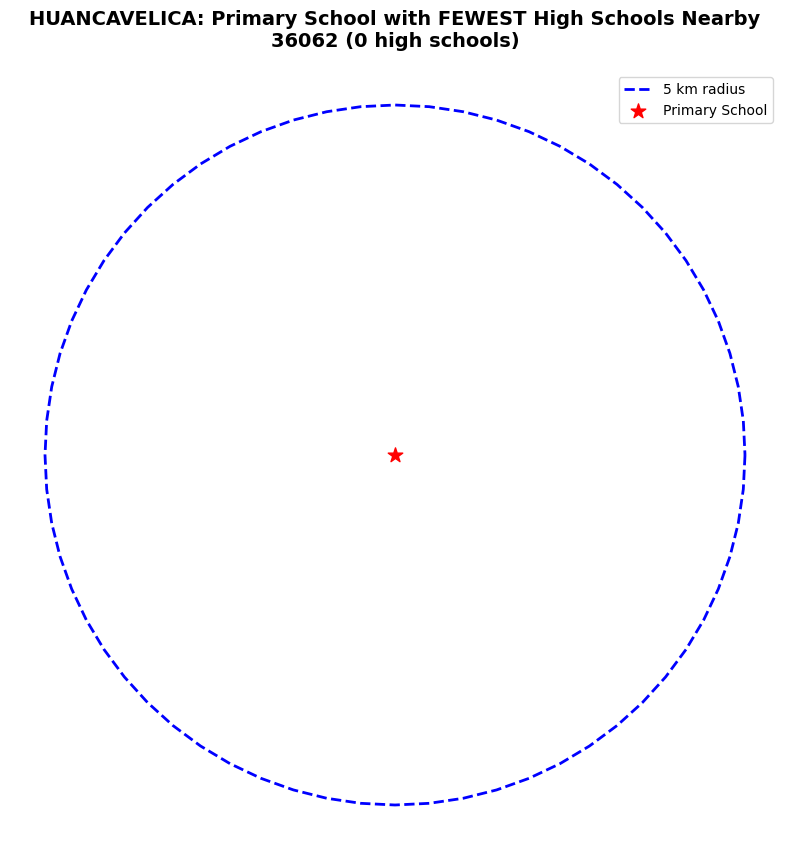

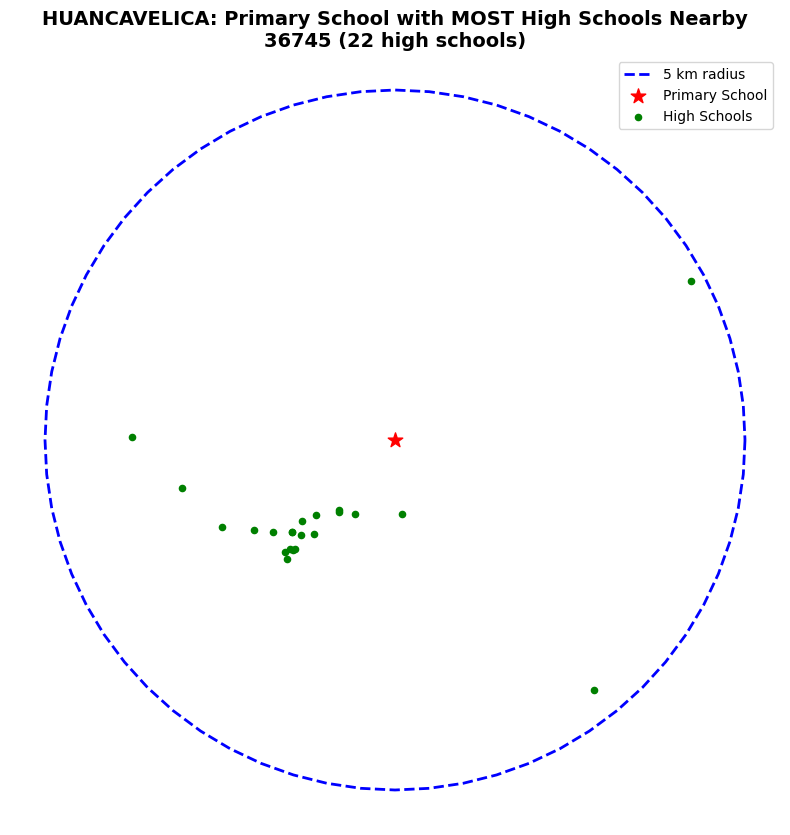

C:\Users\brfm1\AppData\Local\Temp\ipykernel_27200\1929970853.py:54: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  high_schools_within.plot(ax=ax, color='green', markersize=20, label='High Schools')


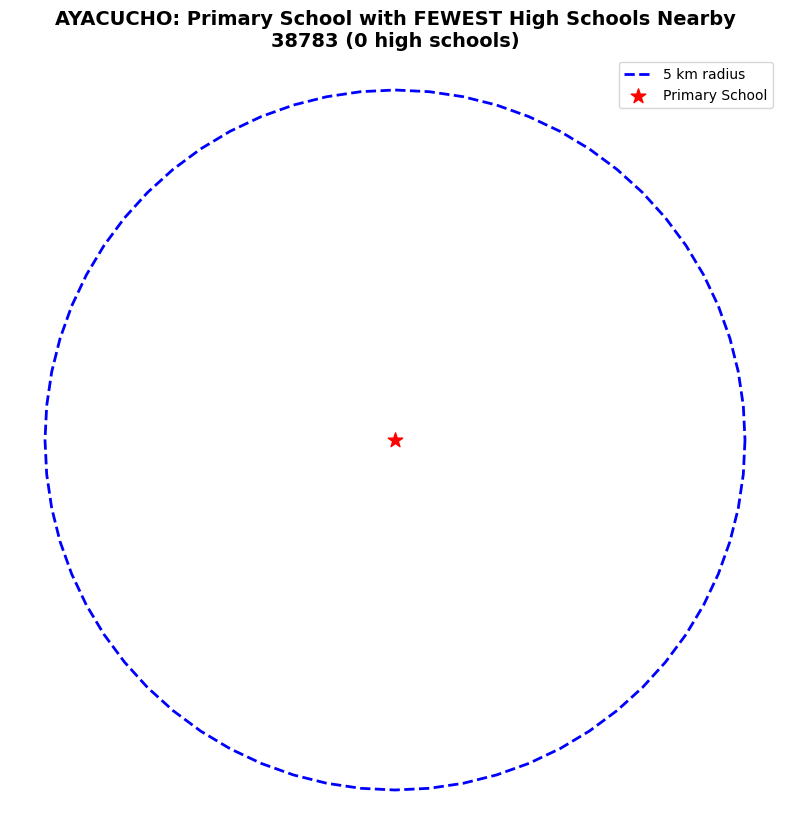

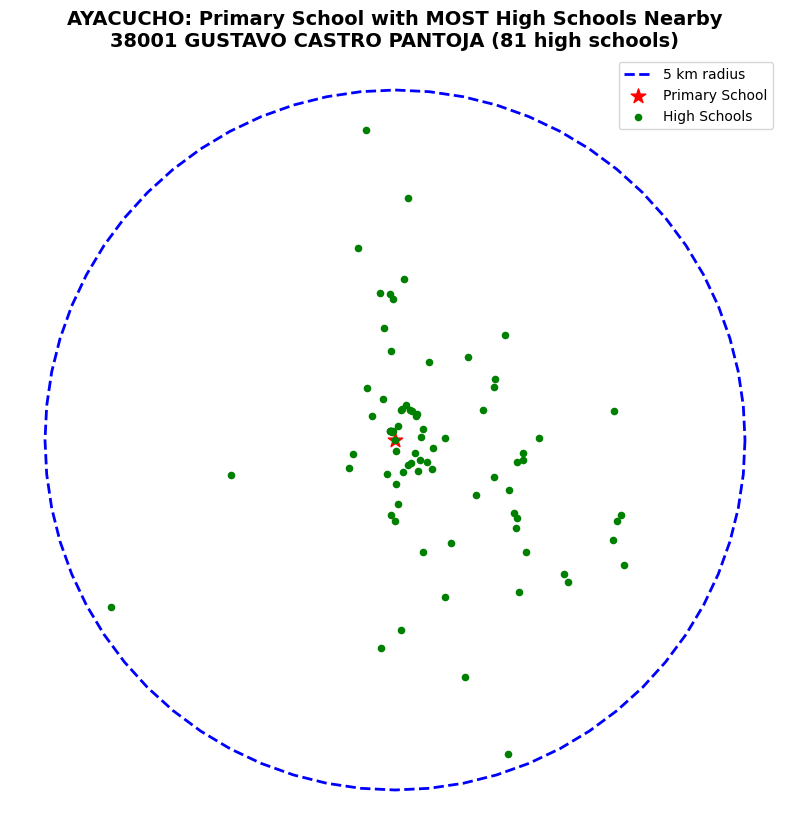

In [7]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import matplotlib.pyplot as plt

#Task 2

# Convert DataFrame to GeoDataFrame
gdf_schools = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitud, df.Latitud), crs="EPSG:4326")

# Define regions and filter data
regions = ['HUANCAVELICA', 'AYACUCHO']
gdf_filtered = gdf_schools[gdf_schools['Departamento'].str.upper().isin(regions)]

# Separate primary and secondary schools
gdf_primary = gdf_filtered[gdf_filtered['Nivel / Modalidad'].str.contains('Primaria', case=False)]
gdf_secondary = gdf_filtered[gdf_filtered['Nivel / Modalidad'].str.contains('Secundaria', case=False)]

# Project data to UTM CRS
utm_crs = 'EPSG:32718'
gdf_primary_proj = gdf_primary.to_crs(utm_crs)
gdf_secondary_proj = gdf_secondary.to_crs(utm_crs)

# 5km radius buffers around primary schools
gdf_primary_proj['buffer_5km'] = gdf_primary_proj.geometry.buffer(5000)

# Counting high schools in buffers
def count_high_schools(buffer_geom, secondary_schools):
    return secondary_schools.within(buffer_geom).sum()

# Counting high schools within 5km radius
gdf_primary_proj['num_highschools_nearby'] = gdf_primary_proj['buffer_5km'].apply(
    lambda x: count_high_schools(x, gdf_secondary_proj))

# Analysis per Region
for region in regions:
    primary_region = gdf_primary_proj[gdf_primary_proj['Departamento'].str.upper() == region]

    # Primary schools with minimum and maximum nearby high schools
    school_min = primary_region.loc[primary_region['num_highschools_nearby'].idxmin()]
    school_max = primary_region.loc[primary_region['num_highschools_nearby'].idxmax()]

    # Plotting 
    def plot_proximity(school, secondary_schools, region_name, proximity_type):
        fig, ax = plt.subplots(figsize=(10, 10))

        # Plot buffer
        buffer_gdf = gpd.GeoDataFrame(geometry=[school.buffer_5km], crs=utm_crs)
        buffer_gdf.boundary.plot(ax=ax, color='blue', linestyle='--', linewidth=2, label='5 km radius')

        # Plot primary school
        gpd.GeoSeries(school.geometry).plot(ax=ax, color='red', markersize=120, marker='*', label='Primary School')

        # High schools within buffer
        high_schools_within = secondary_schools[secondary_schools.within(school.buffer_5km)]
        high_schools_within.plot(ax=ax, color='green', markersize=20, label='High Schools')

        # Plot formatting
        ax.set_title(f"{region_name}: Primary School with {proximity_type} High Schools Nearby\n"
                     f"{school['Nombre de SS.EE.']} ({int(school['num_highschools_nearby'])} high schools)",
                     fontsize=14, fontweight='bold')
        ax.legend()
        ax.axis('off')
        plt.show()

    # Plot schools per region
    plot_proximity(school_min, gdf_secondary_proj, region, "FEWEST")
    plot_proximity(school_max, gdf_secondary_proj, region, "MOST")


In [9]:
import pandas as pd
import geopandas as gpd
import folium
from folium import Choropleth, LayerControl

#Task 3: Choropleth Maps - For all the districts in the country

# Standardize column names
df['Distrito'] = df['Distrito'].str.upper()
df['Nivel / Modalidad'] = df['Nivel / Modalidad'].str.upper()

# Rename for consistency
peru_gdf.rename(columns={'NOMBDEP': 'Departamento', 'NOMBDIST': 'Distrito'}, inplace=True)
peru_gdf['Distrito'] = peru_gdf['Distrito'].str.upper()

# Level filters and colors
levels = {
    'INICIAL': 'Reds',
    'PRIMARIA': 'Blues',
    'SECUNDARIA': 'Greens'
}

# Base folium map of Peru
m = folium.Map(location=[-9.19, -75.02], zoom_start=5, tiles='CartoDB positron')

# Count schools per district for each level
for level, color in levels.items():
    df_level = df[df['Nivel / Modalidad'].str.contains(level, na=False)]
    school_counts = df_level.groupby('Distrito').size().reset_index(name='num_schools')
    
    # Merge with shapefile
    merged = peru_gdf.merge(school_counts, on='Distrito', how='left').fillna(0)

    # Convert GeoDataFrame to GeoJSON for Folium
    geojson = merged.to_json()

    # Add layer to map
    choropleth = Choropleth(
        geo_data=geojson,
        name=level.title(),
        data=merged,
        columns=['Distrito', 'num_schools'],
        key_on='feature.properties.Distrito',
        fill_color=color,
        fill_opacity=0.7,
        line_opacity=0.2,
        legend_name=f'{level.title()} Schools per District',
        nan_fill_color='white'
    ).add_to(m)

# Add layer control
LayerControl().add_to(m)

# Save map to HTML
m.save(r"C:\Users\brfm1\OneDrive\Documentos\Geospatial Analysis of Schools in Peru\folium_school_choropleth.html")


In [11]:
import pandas as pd
import geopandas as gpd
import folium
from shapely.geometry import Point
from folium import Circle, Marker, Map, Icon

#Task 4

# Load and prepare school data
df = pd.read_excel(r"C:\Users\brfm1\OneDrive\Documentos\Geospatial Analysis of Schools in Peru\listado_iiee.xlsx")
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitud, df.Latitud), crs='EPSG:4326')

# Filter to only Ayacucho and Huancavelica
regions = ['AYACUCHO', 'HUANCAVELICA']
gdf = gdf[gdf['Departamento'].str.upper().isin(regions)]

# Separate primary and secondary schools
gdf_primary = gdf[gdf['Nivel / Modalidad'].str.contains('Primaria', case=False, na=False)]
gdf_secondary = gdf[gdf['Nivel / Modalidad'].str.contains('Secundaria', case=False, na=False)]

# Project to UTM for accurate distance calculations
gdf_primary_utm = gdf_primary.to_crs('EPSG:32718')
gdf_secondary_utm = gdf_secondary.to_crs('EPSG:32718')

# Compute 5km buffers and count nearby high schools
gdf_primary_utm['buffer_5km'] = gdf_primary_utm.geometry.buffer(5000)
gdf_primary_utm['highschool_count'] = gdf_primary_utm['buffer_5km'].apply(
    lambda buf: gdf_secondary_utm.within(buf).sum()
)

# Reproject back to EPSG:4326 for Folium
gdf_primary_wgs = gdf_primary_utm.to_crs('EPSG:4326')
gdf_secondary_wgs = gdf_secondary_utm.to_crs('EPSG:4326')

# Function to create a single regional map
def create_region_map(region_name, primary_schools, secondary_schools):
    region_df = primary_schools[primary_schools['Departamento'].str.upper() == region_name]

    # Identify:
    min_schools = region_df[region_df['highschool_count'] == 0]
    max_school = region_df.loc[region_df['highschool_count'].idxmax()]

    # Center map on average location
    avg_lat = region_df.geometry.y.mean()
    avg_lon = region_df.geometry.x.mean()
    fmap = Map(location=[avg_lat, avg_lon], zoom_start=8, tiles='OpenStreetMap')

    # Plot primary schools with 0 high schools nearby
    for _, row in min_schools.iterrows():
        Circle(
            location=(row.geometry.y, row.geometry.x),
            radius=5000,
            color='red',
            fill=True,
            fill_opacity=0.2,
            tooltip=f"0 high schools\n{row['Nombre de SS.EE.']}"
        ).add_to(fmap)

        Marker(
            location=(row.geometry.y, row.geometry.x),
            icon=Icon(color='red', icon='times', prefix='fa'),
            popup=f"{row['Nombre de SS.EE.']}\n(0 high schools)"
        ).add_to(fmap)

    # Plot the primary school with most high schools nearby
    Circle(
        location=(max_school.geometry.y, max_school.geometry.x),
        radius=5000,
        color='green',
        fill=True,
        fill_opacity=0.2,
        tooltip=f"{int(max_school['highschool_count'])} high schools\n{max_school['Nombre de SS.EE.']}"
    ).add_to(fmap)

    Marker(
        location=(max_school.geometry.y, max_school.geometry.x),
        icon=Icon(color='green', icon='star', prefix='fa'),
        popup=f"{max_school['Nombre de SS.EE.']}\n({int(max_school['highschool_count'])} high schools)"
    ).add_to(fmap)

    # Plot the nearby secondary schools around max school
    max_buffer = max_school['buffer_5km']
    max_buffer_wgs = gpd.GeoSeries([max_buffer], crs='EPSG:32718').to_crs('EPSG:4326')[0]
    nearby_highschools = secondary_schools[secondary_schools.within(max_buffer_wgs)]

    for _, hs in nearby_highschools.iterrows():
        Marker(
            location=(hs.geometry.y, hs.geometry.x),
            icon=Icon(color='blue', icon='graduation-cap', prefix='fa'),
            popup=f"High School: {hs['Nombre de SS.EE.']}"
        ).add_to(fmap)

    # Title bar
    fmap.get_root().html.add_child(folium.Element(f"""
        <h4 style='position: fixed; 
                   top: 10px; left: 50px; width: 90%;
                   z-index: 9999;
                   font-size: 16px;
                   background-color: white;
                   padding: 10px;
                   border: 1px solid grey;'>
        {region_name.title()} — Proximity Analysis of Primary Schools
        <br><span style='color:red;'>Red</span>: Primary schools with 0 nearby high schools
        <br><span style='color:green;'>Green</span>: Primary school with most nearby high schools
        <br><span style='color:blue;'>Blue</span>: Nearby secondary schools
        </h4>
    """))
    
    return fmap

# Create and save maps
for region in regions:
    fmap = create_region_map(region, gdf_primary_wgs, gdf_secondary_wgs)
    fmap.save(fr"C:\Users\brfm1\OneDrive\Documentos\Geospatial Analysis of Schools in Peru\proximity_{region.lower()}_map.html")
